<a href="https://colab.research.google.com/github/Angelorigo/MODELOS-ESTOCASTICOS/blob/main/Algoritmo_para_simular_una_Cadena_de_Markov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#**ÁLVAREZ SERVÍN ÁNGEL RODRIGO**

##- MATEMÁTICA ALGORÍTMICA.
##- MODELOS ESTOCÁSTICOS.
##- ESFM IPN, MARZO 2026.

Este programa está basado en el juego porpuesto al inicio del curso sobre una ficha en un tablero de cuatro colores, por lo que dada una distribución inicial, y su matriz de transición P, se haga una caminata aleatoria 100 veces y calcular su probabilidad acumulada.

Se pidió que fuera con 100 pasos, y la ultima actualización permite que el usuario pueda ingresar tanto el vector de distribución inicial, como la matriz de transición en sí.

En caso de querer visualizar el código original, se encuentra en el repositorio de github bajo el nombre de Tablero_n_pasos.py.

Como siempre, se declaran las librerías:

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

Aquí definimos los colores e imprimimos la instrucción al usuario de ingresar los datos de manera correcta.

In [2]:
# [A = Azul, N = Naranja, R = Rojo, V = Verde]
colores = ['A', 'N', 'R', 'V']

print(f"===========================================================================")
print("CAMINATA ALEATORIA EN EL TABLERO: Azul, Naranja, Rojo, Verde.\n")
print("Por favor, ingrese los valores deseados para la matriz de transición de 4x4")
print("de tal manera que sumados, den 1; separado por comas (ej, 0.5 0.0 0.4 0.1)")

CAMINATA ALEATORIA EN EL TABLERO: Azul, Naranja, Rojo, Verde.

Por favor, ingrese los valores deseados para la matriz de transición de 4x4
de tal manera que sumados, den 1; separado por comas (ej, 0.5 0.0 0.4 0.1)


Posteriormente, Se guardan los valores fila por fila para la matriz P, para después ingresar el vector de distribución inicial.

In [3]:
P_lista = []
for i in range(4):
    entrada_fila = input(f"Probabiidades de salto desde {colores[i]}: ")
    fila = [float(x) for x in entrada_fila.split()]
    P_lista.append(fila)
P = np.array(P_lista)
n = 100
print(f"===========================================================================")
print("Ahora, ingrese el vector de distribución inicial de 1x4, separado por comas y que sumen 1.")
entrada_a = input("VECTOR INICIAL: ")
a = np.array([float(x) for x in entrada_a.split()])

Probabiidades de salto desde A: 0.2 0.2 0.2 0.4
Probabiidades de salto desde N: 0.4 0.2 0.2 0.2
Probabiidades de salto desde R: 0.4 0.2 0.4 0.0
Probabiidades de salto desde V: 0.0 0.4 0.2 0.4
Ahora, ingrese el vector de distribución inicial de 1x4, separado por comas y que sumen 1.
VECTOR INICIAL: 0.25 0.25 0.25 0.25


Ahora se imprimen los datos para verificar que estén correctos, en caso de que estén mal, i.e., que las filas no sumen uno, el proceso termina.

In [4]:
print(f"===========================================================================")
print(f"                 Tu vector de valores iniciales es:")
print(f"                       {a}")
print(f"===========================================================================")
print(f"                    Tu matriz de transición es:")
print(f"{P}")
print(f"===========================================================================")
print(f"    Considere: A = Azul, N = Naranja, R = Rojo, V = Verde")

X = []  # X Guarda el camino

                 Tu vector de valores iniciales es:
                       [0.25 0.25 0.25 0.25]
                    Tu matriz de transición es:
[[0.2 0.2 0.2 0.4]
 [0.4 0.2 0.2 0.2]
 [0.4 0.2 0.4 0. ]
 [0.  0.4 0.2 0.4]]
    Considere: A = Azul, N = Naranja, R = Rojo, V = Verde


En esta parte se hace uso de la librería "random" para determinar valores aleatorios que tomará la caminata en cada iteración:

In [5]:
X_0 = np.random.choice([0, 1, 2, 3], p = a)
X.append(X_0)

Cálculo de la Probabilidad Acumulada, denotada PA:

In [6]:
PA = a[X_0]

Bucle:

In [7]:
print(f"---------------------------------------------------------------------------")
for i in range (1, n+1):
    j = X[i-1]
    p = P[j, :]
    X_i = np.random.choice([0, 1, 2, 3], p=p)
    X.append(X_i)
    PA *= P[j, X_i]
    print(f"{i}, de {colores[j]}, a {colores[X_i]}; Con probabilidad: {P[j, X_i]}")
    print(f"---------------------------------------------------------------------------")

camino = [colores[estado] for estado in X]

---------------------------------------------------------------------------
1, de R, a N; Con probabilidad: 0.2
---------------------------------------------------------------------------
2, de N, a V; Con probabilidad: 0.2
---------------------------------------------------------------------------
3, de V, a N; Con probabilidad: 0.4
---------------------------------------------------------------------------
4, de N, a A; Con probabilidad: 0.4
---------------------------------------------------------------------------
5, de A, a A; Con probabilidad: 0.2
---------------------------------------------------------------------------
6, de A, a A; Con probabilidad: 0.2
---------------------------------------------------------------------------
7, de A, a N; Con probabilidad: 0.2
---------------------------------------------------------------------------
8, de N, a A; Con probabilidad: 0.4
---------------------------------------------------------------------------
9, de A, a V; Con probabilid

Impresión del Camino recorrido:

In [8]:
print(f"\n===========================================================================")
print(f"La trayectoria fue:\n{' -> '.join(camino)}")
print(f"===========================================================================")
print(f"Probabilidad de llegar a este evento, dado el camino anterior: {PA:.20f}")
print(f"===========================================================================")


La trayectoria fue:
R -> N -> V -> N -> A -> A -> A -> N -> A -> V -> R -> R -> A -> A -> A -> V -> V -> V -> N -> A -> V -> N -> A -> R -> A -> R -> A -> V -> V -> V -> N -> N -> V -> V -> N -> R -> A -> N -> A -> A -> V -> V -> V -> N -> N -> R -> R -> A -> N -> R -> R -> R -> R -> A -> N -> V -> V -> N -> R -> N -> V -> N -> R -> R -> N -> R -> A -> V -> N -> A -> A -> V -> V -> V -> N -> A -> V -> N -> N -> V -> N -> A -> R -> A -> V -> V -> N -> R -> R -> A -> V -> R -> R -> R -> A -> N -> A -> A -> N -> R -> R
Probabilidad de llegar a este evento, dado el camino anterior: 0.00000000000000000000


Dadas las iteraciones y los valores arrojados por "random", en este paso se hace el cálculo de cuántas veces se cayó en cada estado.

In [9]:
print("---------------------------------------------------------------------------")
print("PORCENTAJES:\n")
for i in range(4):
    visita = X.count(i)
    porcentaje = (visita / len(X)) * 100
    print(f"{colores[i]}: Cayó {visita} veces ({porcentaje:.2f}%)")
print("---------------------------------------------------------------------------")

---------------------------------------------------------------------------
PORCENTAJES:

A: Cayó 26 veces (25.74%)
N: Cayó 25 veces (24.75%)
R: Cayó 24 veces (23.76%)
V: Cayó 26 veces (25.74%)
---------------------------------------------------------------------------


Graficación de los estados:

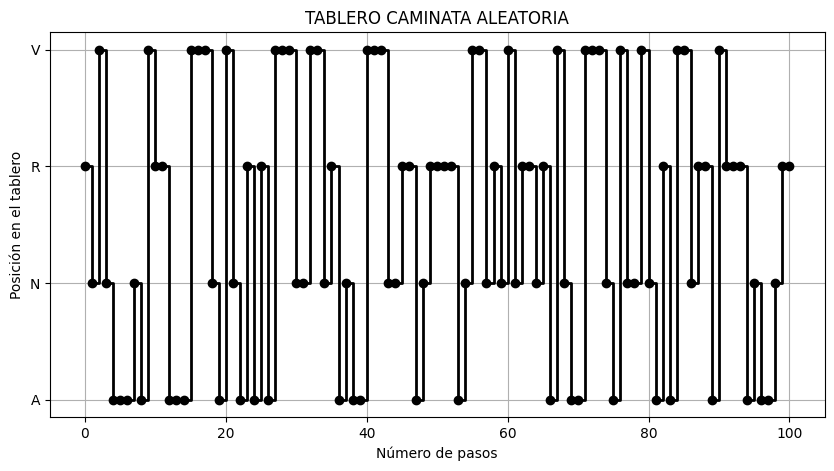

In [10]:
plt.figure(figsize=(10, 5))
plt.step(range(n+1), X, where = 'post', marker = 'o', color = 'black', linewidth = 2)
plt.yticks([0, 1, 2, 3], colores)
plt.xlabel("Número de pasos")
plt.ylabel("Posición en el tablero")
plt.title("TABLERO CAMINATA ALEATORIA")
plt.grid(True)
plt.show()
